# Neural networks - straightforward guide

In [1]:
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, log_loss, precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

I0000 00:00:1778274336.724191   19601 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%matplotlib inline

plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['figure.facecolor'] = 'silver'

# Kaggle
https://www.kaggle.com/uciml/pima-indians-diabetes-database

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/'

df_red = pd.read_csv(url + 'winequality-red.csv', sep=';')
df_white = pd.read_csv(url + 'winequality-white.csv', sep=';')
df = pd.concat([
    df_red.assign(color_red=True),
    df_white.assign(color_red=False),
]).reset_index(drop=True)

display(df)
display(df['quality'].value_counts().sort_index())
X = df.drop(columns='quality').astype(float).values
y = df['quality'].values >= 7

descr = requests.get(url + 'winequality.names').text
print(descr)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,True
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,True
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,True
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,True
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,False
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,False
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,False
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,False


quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Citation Request:
  This dataset is public available for research. The details are described in [Cortez et al., 2009]. 
  Please include this citation if you plan to use this database:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  Available at: [@Elsevier] http://dx.doi.org/10.1016/j.dss.2009.05.016
                [Pre-press (pdf)] http://www3.dsi.uminho.pt/pcortez/winequality09.pdf
                [bib] http://www3.dsi.uminho.pt/pcortez/dss09.bib

1. Title: Wine Quality 

2. Sources
   Created by: Paulo Cortez (Univ. Minho), Antonio Cerdeira, Fernando Almeida, Telmo Matos and Jose Reis (CVRVV) @ 2009
   
3. Past Usage:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 016

# Recap

In [4]:
rf = RandomForestClassifier(n_estimators=20, min_samples_leaf=3, max_features=0.5, n_jobs=-1, bootstrap=True)
rf.fit(X, y)

accuracy_score(y, rf.predict(X))

0.9722949053409266

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y, rf.predict(X), target_names=['bad', 'good']))

              precision    recall  f1-score   support

         bad       0.97      1.00      0.98      5220
        good       0.99      0.87      0.93      1277

    accuracy                           0.97      6497
   macro avg       0.98      0.93      0.95      6497
weighted avg       0.97      0.97      0.97      6497



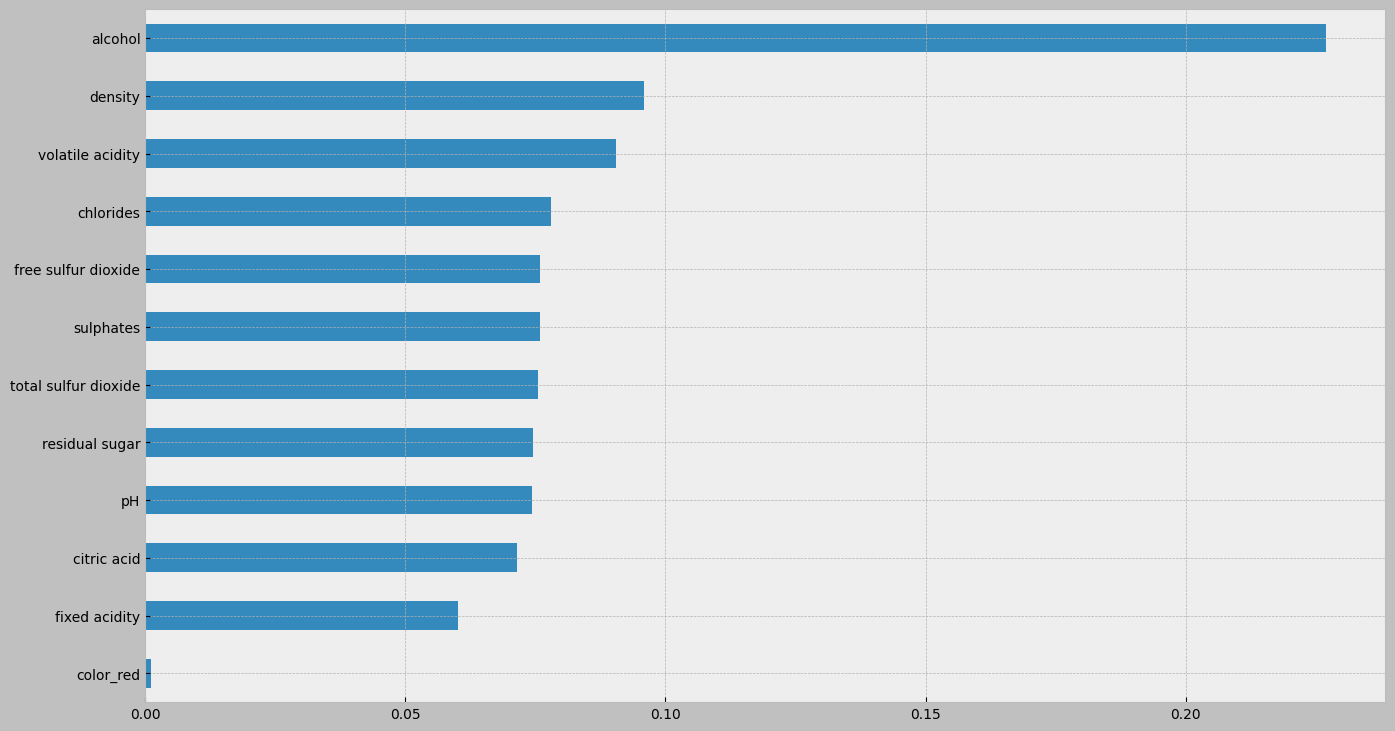

In [6]:
pd.Series(rf.feature_importances_, index=df.drop(columns='quality').columns).sort_values().plot.barh();

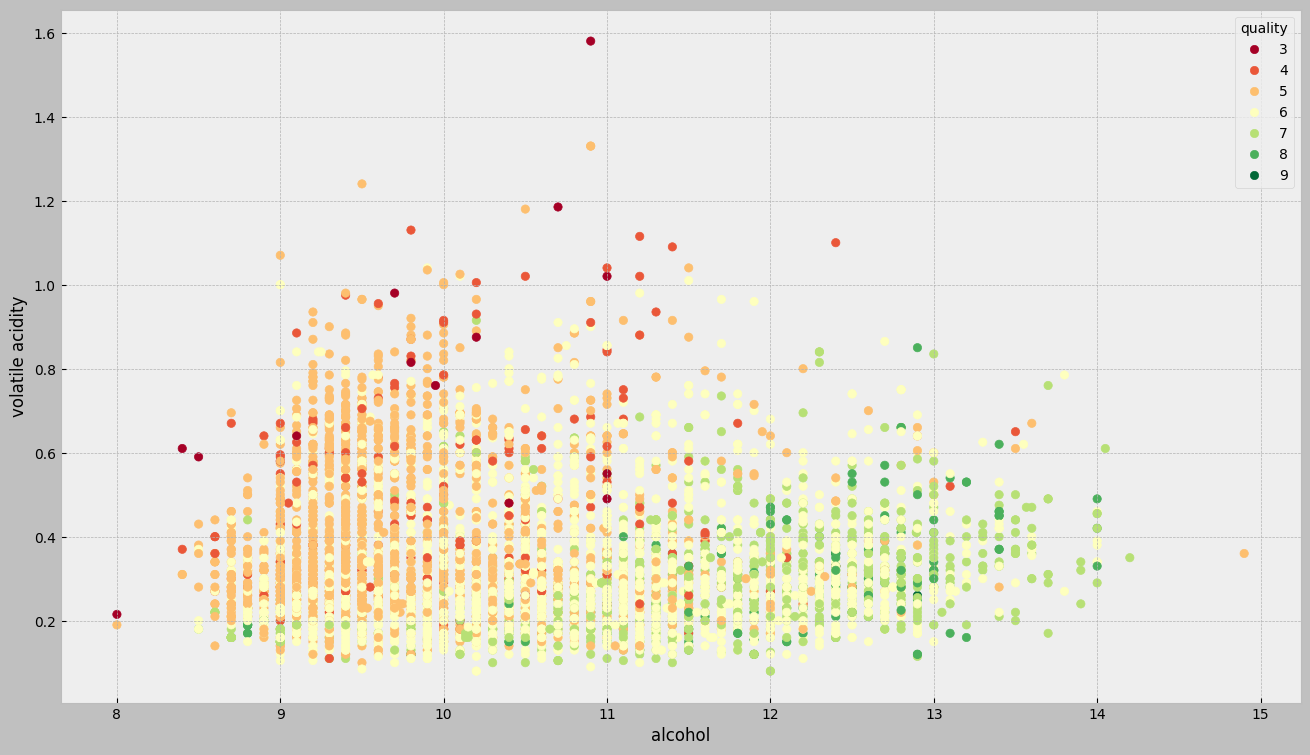

In [7]:
sns.scatterplot(x='alcohol', y='volatile acidity', hue='quality', data=df, palette='RdYlGn', ec=None);

# Train a neural network
https://keras.io/  
https://www.tensorflow.org/guide/keras

In [8]:
# Model prediction expressed as probabilities
rf.predict_proba(X[:10])

array([[1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.98571429, 0.01428571],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.69875   , 0.30125   ],
       [0.79892857, 0.20107143],
       [1.        , 0.        ]])

[Log loss visually explained](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)

TL;DR:

$\huge H(y, pred) = -\frac{\sum_{i=1}^{N} y_ilog(pred_i) \ + \ (1 - y_i)log(1-pred_i)}{N}$

Because $y$ is always 0 or 1, it "toggles" the terms of the summation on/off and it could be rewritten as:
$\large -\frac{1}{N}\sum_{i=1}^{N} log(1 - err_i)$

In [9]:
log_loss(y, rf.predict_proba(X)[:, 1])

0.14010885516991517

In [10]:
neural_net = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=X.shape[1:]),
    keras.layers.Dense(16, activation='relu'),
    
    # outputs in the range 0-1
    keras.layers.Dense(1, activation='sigmoid')
])

neural_net.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
neural_net.summary()

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778274342.874077   19601 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,889 (7.38 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks = []

# Stops training if model's loss doesn't improve for over 3 epochs
callbacks.append(keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.1, mode='auto', patience=5, 
                                               restore_best_weights=True))

# Writes to disk the model with the best accuracy
callbacks.append(keras.callbacks.ModelCheckpoint('neural_net.h5', monitor='accuracy', save_weights_only=False, 
                                                 save_best_only=True, mode='auto'))

history = neural_net.fit(x=X, y=y, validation_split=.2, batch_size=32, epochs=100, callbacks=callbacks)

Epoch 1/100
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4983 - loss: 8.2521

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6865 - loss: 2.9447 - val_accuracy: 0.8100 - val_loss: 0.4899
Epoch 2/100
153/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8103 - loss: 0.4937

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4996 - val_accuracy: 0.8100 - val_loss: 0.4950
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4918 - val_accuracy: 0.8100 - val_loss: 0.4742
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4748 - val_accuracy: 0.8100 - val_loss: 0.4701
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8016 - loss: 0.4722 - val_accuracy: 0.8100 - val_loss: 0.5122
Epoch 6/100
151/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8043 - loss: 0.4527

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8035 - loss: 0.4534 - val_accuracy: 0.7931 - val_loss: 0.4925
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8028 - loss: 0.4485 - val_accuracy: 0.8115 - val_loss: 0.4565


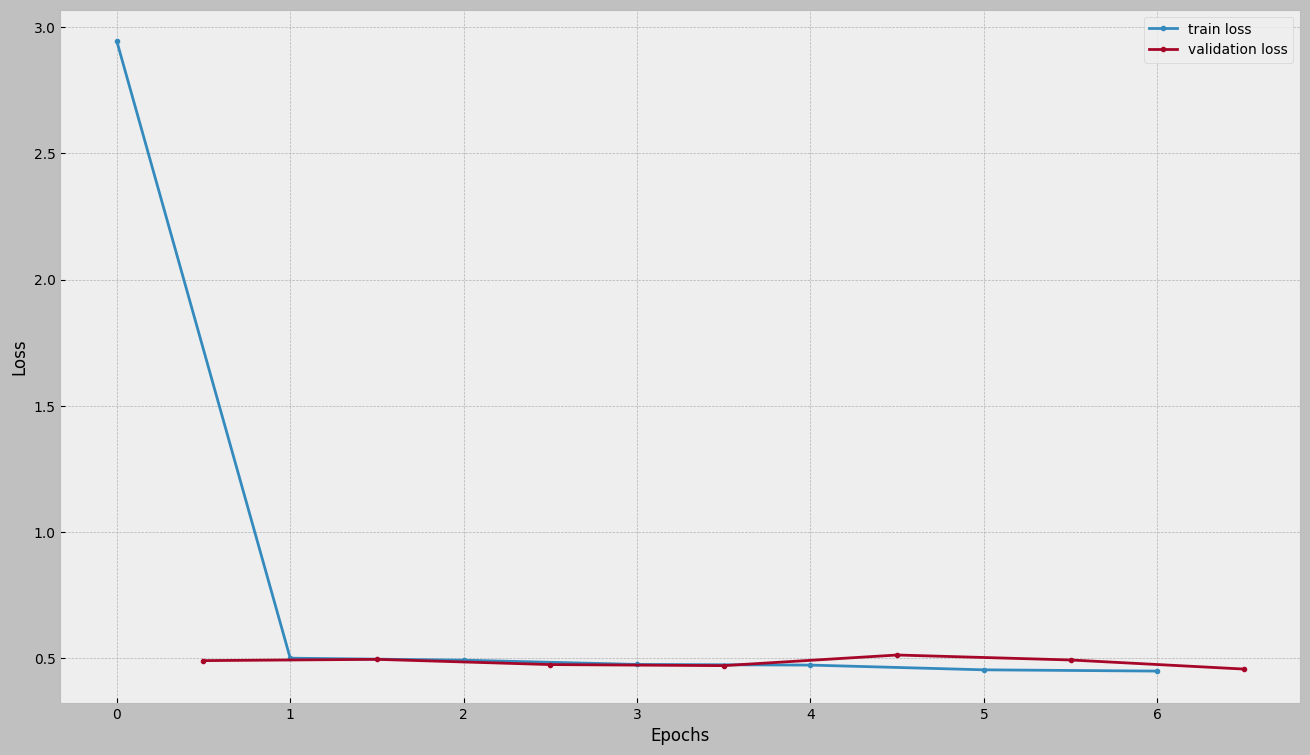

In [12]:
epochs = np.array(history.epoch)

plt.plot(epochs,      history.history['loss'],     label='train loss',      marker='.')
plt.plot(epochs + .5, history.history['val_loss'], label='validation loss', marker='.')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

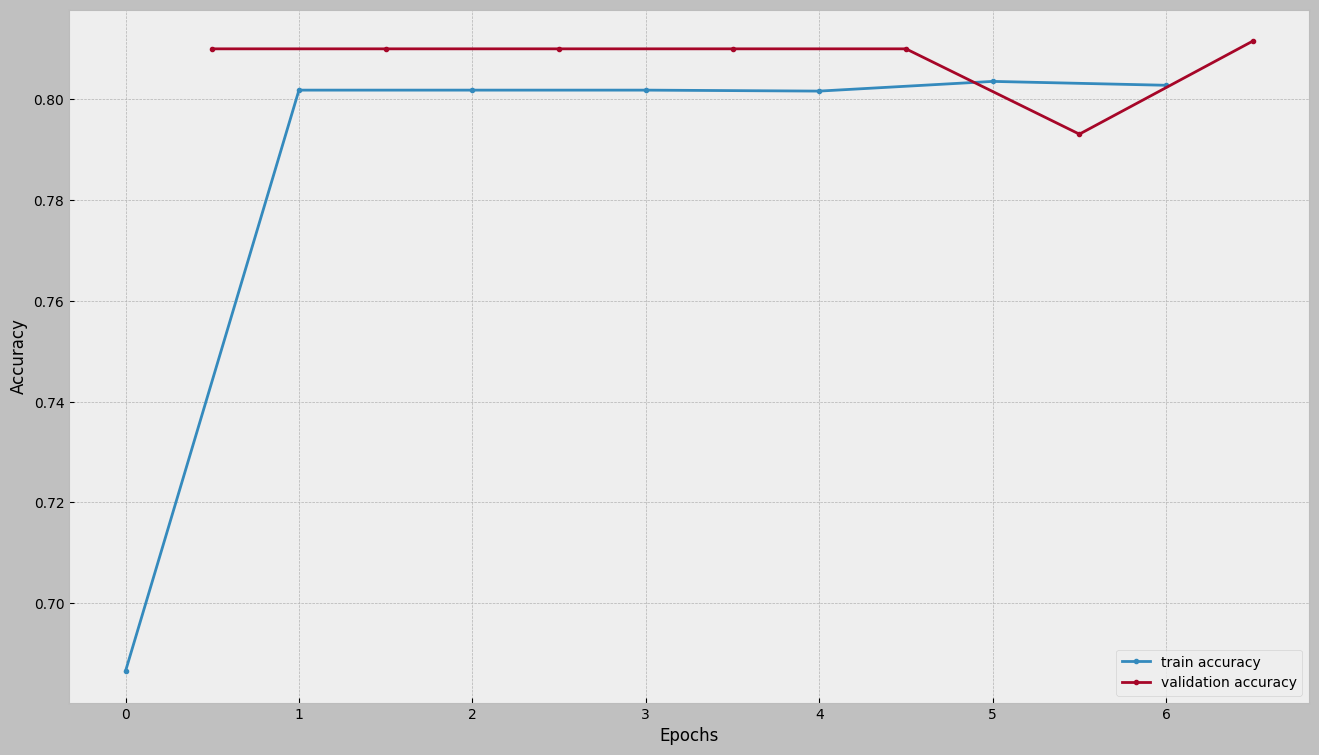

In [13]:
plt.plot(epochs,      history.history['accuracy'],     label='train accuracy',      marker='.')
plt.plot(epochs + .5, history.history['val_accuracy'], label='validation accuracy', marker='.')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

# Single-layer perceptron

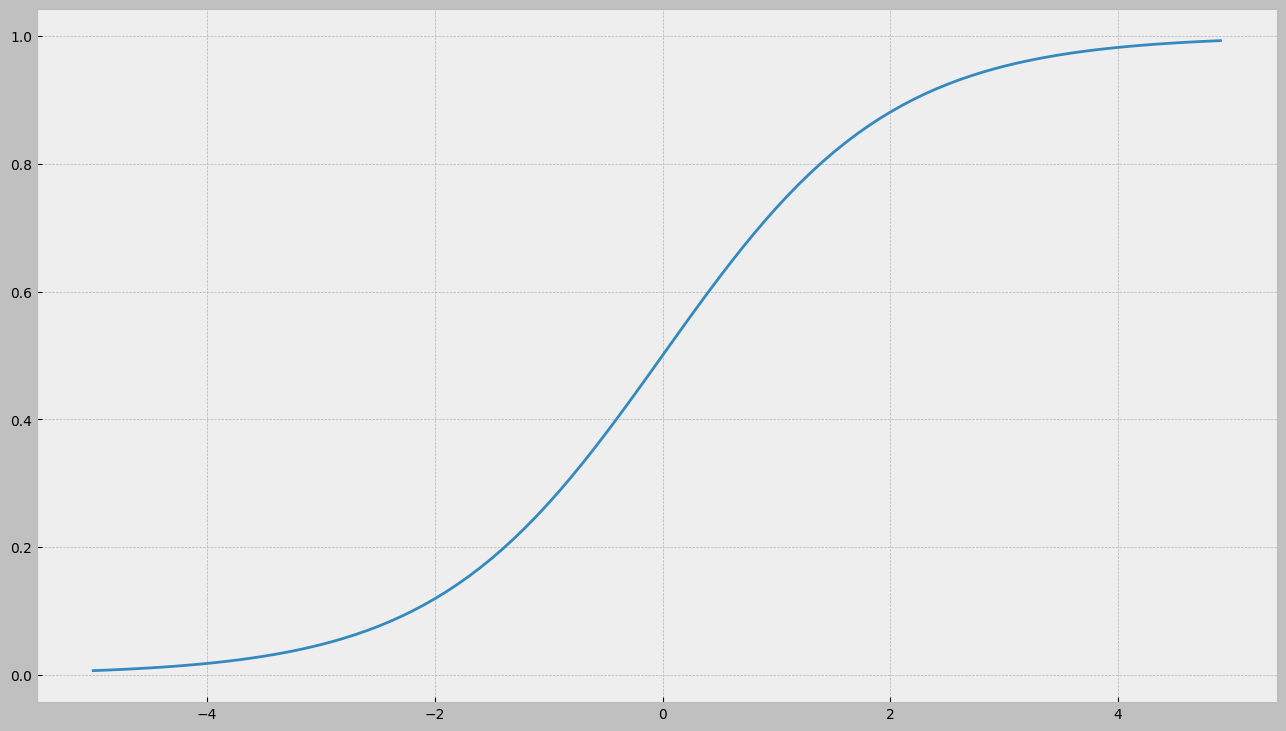

In [14]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5, 5, 0.1)

plt.plot(x, sigmoid(x))
plt.grid(True);

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


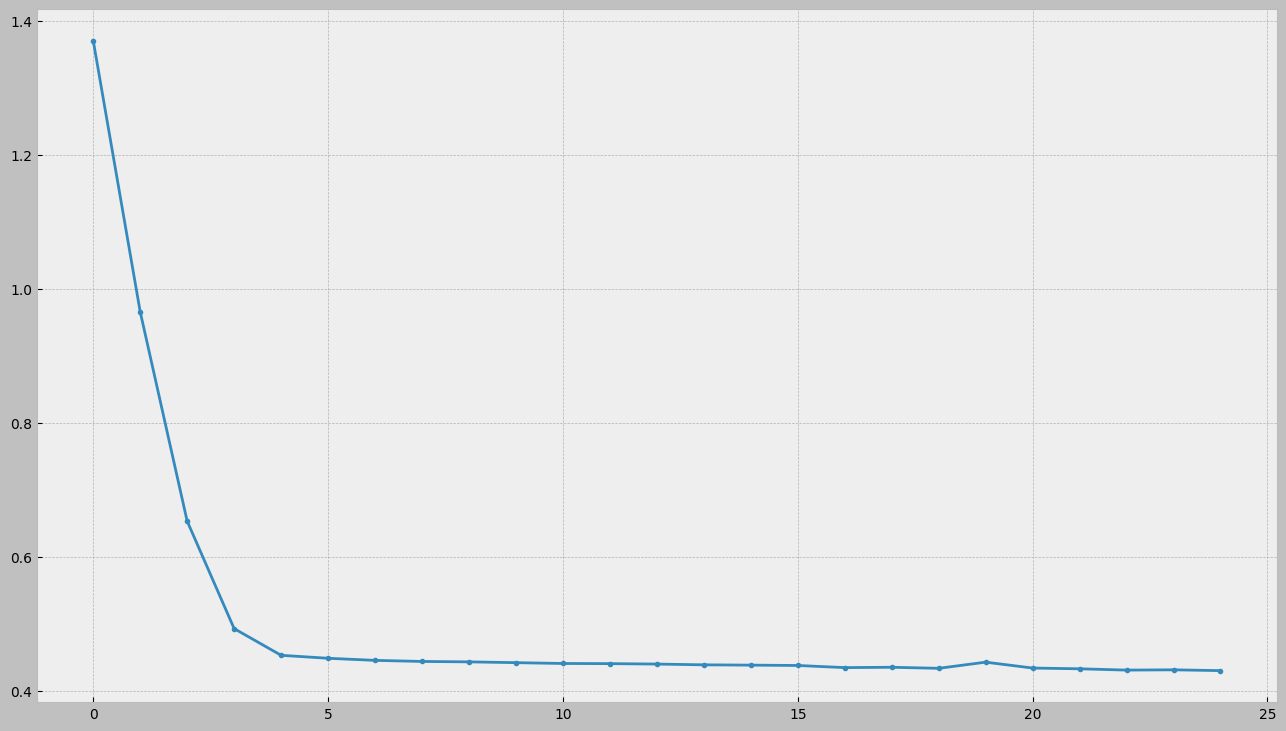

In [15]:
neural_net = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X.shape[1],)),
    keras.layers.Dense(1, activation='sigmoid')
])

neural_net.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

history = neural_net.fit(x=X, y=y, batch_size=32, epochs=25, verbose=False)

plt.plot(history.history['loss'], marker='.');

In [16]:
weights, bias = neural_net.layers[-1].get_weights()
print('Shapes:', weights.shape, bias.shape)
print(weights)
print(bias)

Shapes: (12, 1) (1,)
[[-0.21088827]
 [-1.2576287 ]
 [ 0.04498665]
 [ 0.00276937]
 [-0.7293458 ]
 [ 0.01432394]
 [-0.01276469]
 [-0.3427884 ]
 [-0.8383336 ]
 [-0.28877702]
 [ 0.47039488]
 [-0.5156502 ]]
[-0.39873153]


In [17]:
y_hat = sigmoid(np.dot(X, weights) + bias)

print(log_loss(y, y_hat))
print(accuracy_score(y, y_hat > 0.5))

0.4302254336130525
0.8063721717715869


In [18]:
history.history['loss'][-1], history.history['accuracy'][-1]

(0.42989465594291687, 0.8054486513137817)

# Gradient descent

# By hand

In [19]:
def f(x):
    return x ** 2

def df(x):
    return x * 2

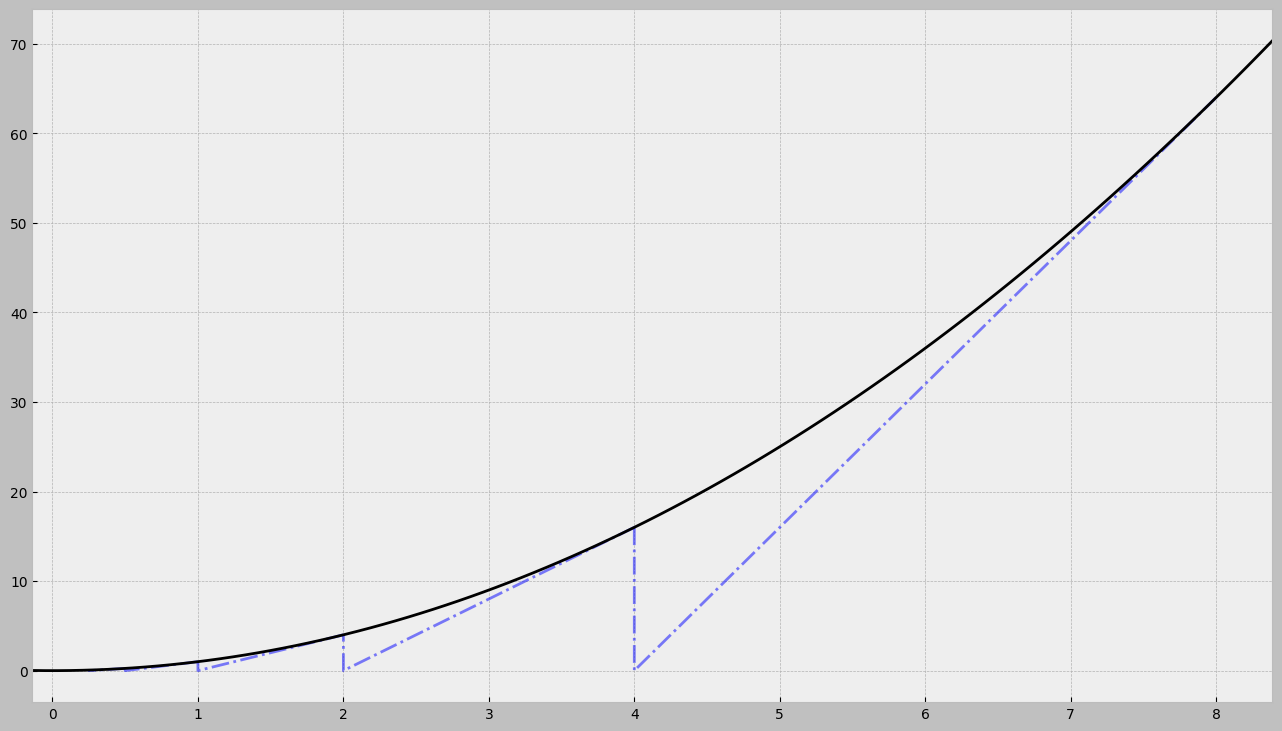

In [20]:
x0 = 8
lr = .25
steps = 5

projections = True
for i in range(steps):
    x1 = x0 - lr * df(x0)
    p1 = f(x0) - lr * df(x0) ** 2
    y1 = f(x1)
    
    # plt.plot([x0, x1], [f(x0), y1], marker='.', c='b')
    if projections:
        plt.plot([x0, x1, x1], [f(x0), p1, y1], ls='-.', alpha=.5, c='b')
    
    x0 = x1
    
xmin, xmax = plt.xlim()
x = np.linspace(*plt.xlim(), 100)
plt.autoscale(False, axis='x')
plt.plot(x, f(x), color='k', label='f(x)');

Complicated functions, like neural nets, can be broken down into elementary functions that we know the derivatives to.

A layer like $\sigma(w \cdot x + b)$ would become $\sigma(\ add(\ mat\_mul(w, x), b))$

From there we apply the chain rule: $f(g(x))' = f'(g(x)) * g'(x)$

Training a neural network is performed through back-propagation, which involves applying the chain rule repeatedly until adjustments are made to all its weights. Fortunately libraries like Tensorflow and PyTorch handle all this busywork behind the scenes.

[Visualisations of neural networks training](https://playground.tensorflow.org/#activation=linear)

## Auto-differentiation example

In [21]:
class Variable:
    var_cnt = 0

    def __init__(
            self,
            value,
            name=None
    ):
        self.value = value
        self.grad = 0
        self.parents = set()
        self._backward = lambda: None

        self.name = name if name != None else f'var_{Variable.var_cnt}'

    def __repr__(self):
        return f'<Variable {self.name} value: {self.value} grad: {self.grad}>'
    
    def __add__(self,other):
        other = other if isinstance(other,Variable) else Variable(other)

        out = Variable(self.value + other.value,name=f'add_{self.name}_{other.name}')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out.parents = {self,other}
        out._backward = _backward

        return out
    
    def __radd__(self,other):
        return self + other
    
    def __mul__(self,other):
        other = other if isinstance(other,Variable) else Variable(other)

        out = Variable(self.value * other.value,name=f'mul_{self.name}_{other.name}')

        def _backward():
            self.grad += out.grad * other.value
            other.grad += out.grad * self.value

        out.parents = {self,other}
        out._backward = _backward

        return out
    
    def __rmul__(self,other):
        return self * other
    
    def backward(self):
        self.grad = 1

        topo_order = []
        visited = set()

        def topo(node):
            if not node in visited:
                visited.add(node)
                for parent in node.parents:
                    topo(parent)
                topo_order.append(node)
        
        topo(self)
        for node in topo_order[::-1]:
            node._backward()

In [22]:
x = Variable(-8)

z = x*x + 5*x + 6
z.backward()

print(x.grad)

-11


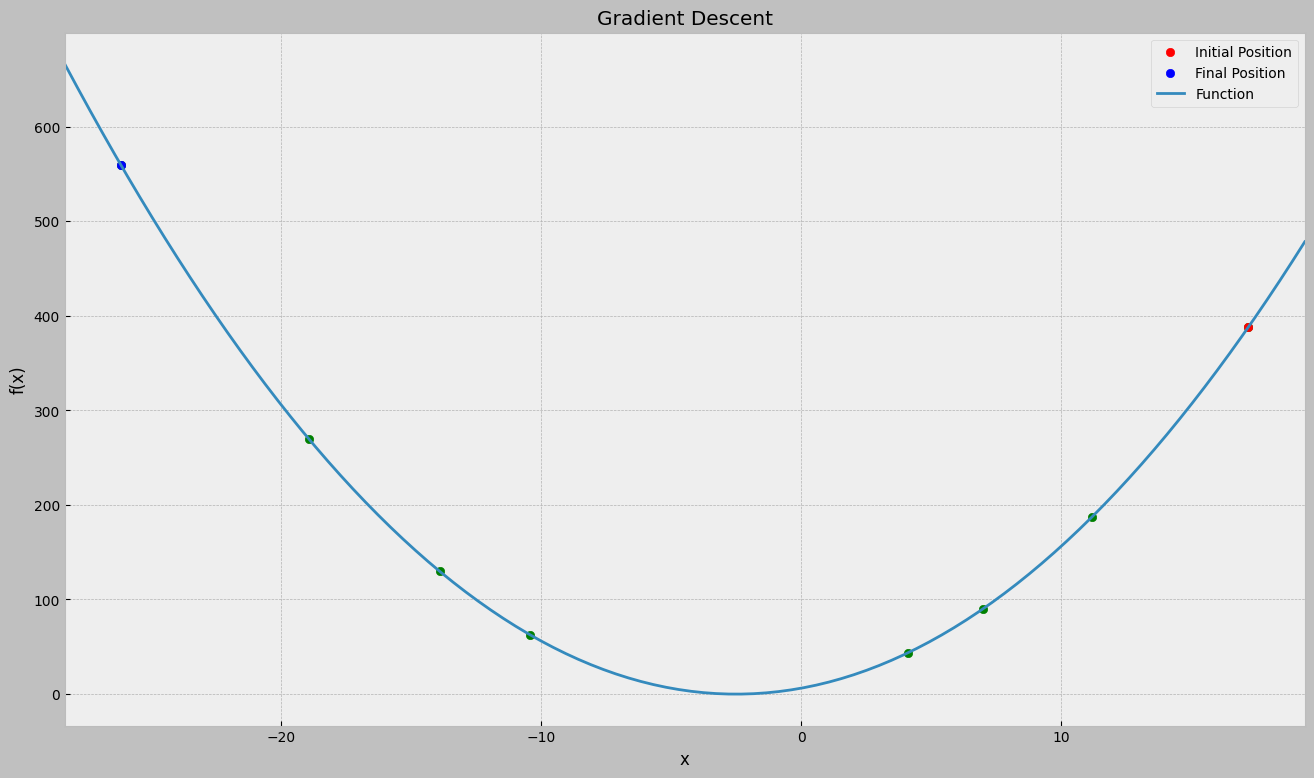

In [23]:
# Our mountain function
def f(x):
    return x*x + 5*x + 6

learning_rate = 1.1
num_steps = 8
x = Variable(-8)

x0 = x.value
for step in range(num_steps):
    x0 = x.value
    y_x = f(x)
    
    y_x.backward()
    x.value -= learning_rate * x.grad
    x.grad = 0
    
    plt.scatter(x.value, f(x).value, color='green')

plt.scatter(x0, f(x0), color='red', label='Initial Position')
plt.scatter(x.value, f(x).value, color='blue', label='Final Position')

xmin, xmax = plt.xlim()
xs = np.linspace(*plt.xlim(), 100)
plt.autoscale(False, axis='x')
plt.plot(xs, f(xs), label='Function')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient Descent')
plt.legend();

# Activation functions - extra decision power

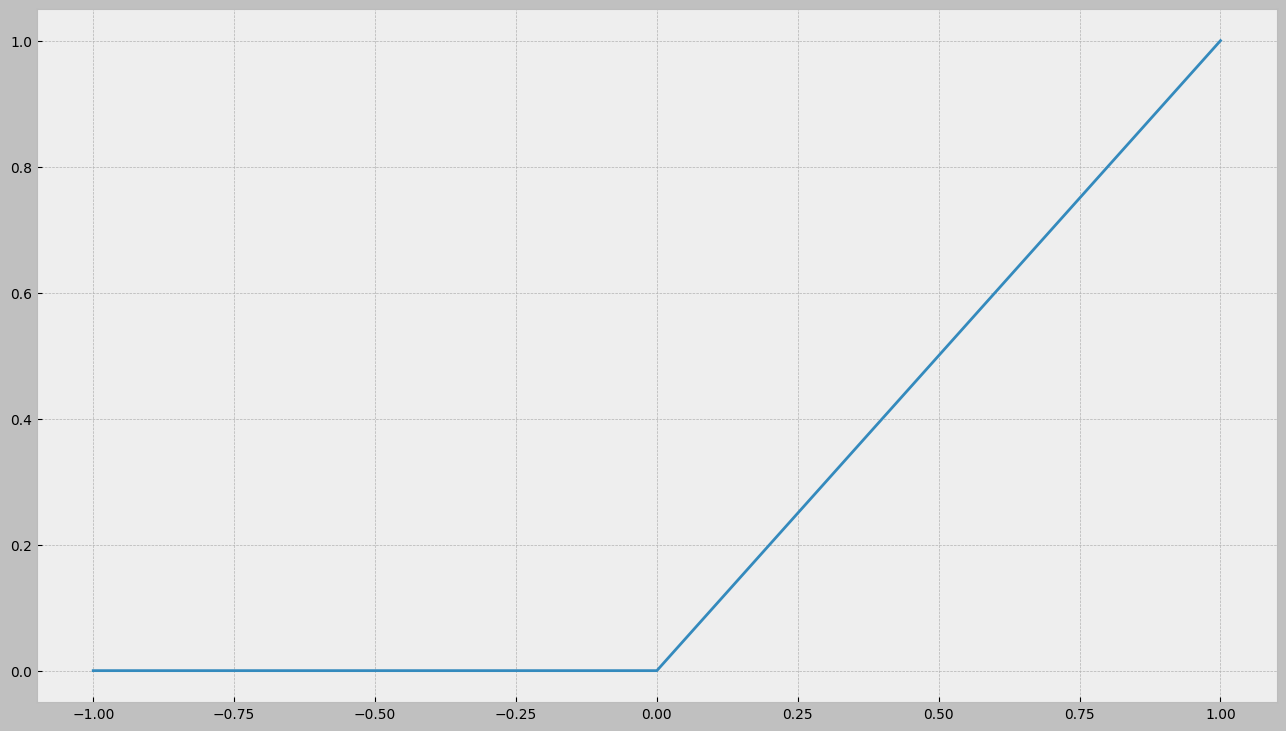

In [24]:
def relu(x):
    return x * (x > 0)

x = np.linspace(-1, 1, 101)
plt.plot(x, relu(x))
plt.grid(True)

In [25]:
neural_net = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X.shape[1],)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

neural_net.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['acc'])
history = neural_net.fit(x=X, y=y, validation_split=.25, batch_size=32, epochs=100, verbose=False)

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


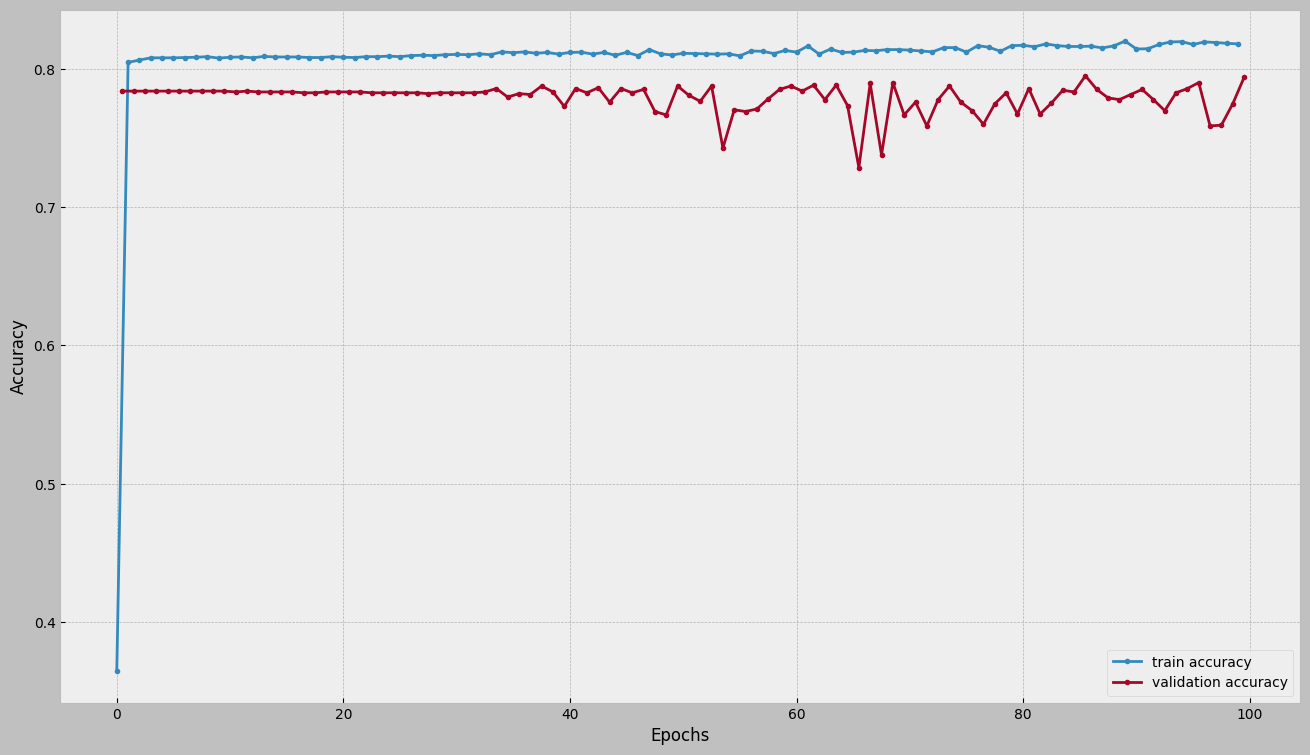

In [26]:
plt.plot(history.history['acc'], label='train accuracy', marker='.')
plt.plot(np.array(history.epoch) + .5, 
         history.history['val_acc'], label='validation accuracy', marker='.')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

# Scaling - using the same units

In [27]:
scaler = StandardScaler()

scaler.fit(X)
X_s = scaler.transform(X)

In [28]:
neural_net = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X.shape[1],)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

neural_net.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['acc'])
history = neural_net.fit(x=X_s, y=y, validation_split=.25, batch_size=32, epochs=100, verbose=False)

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


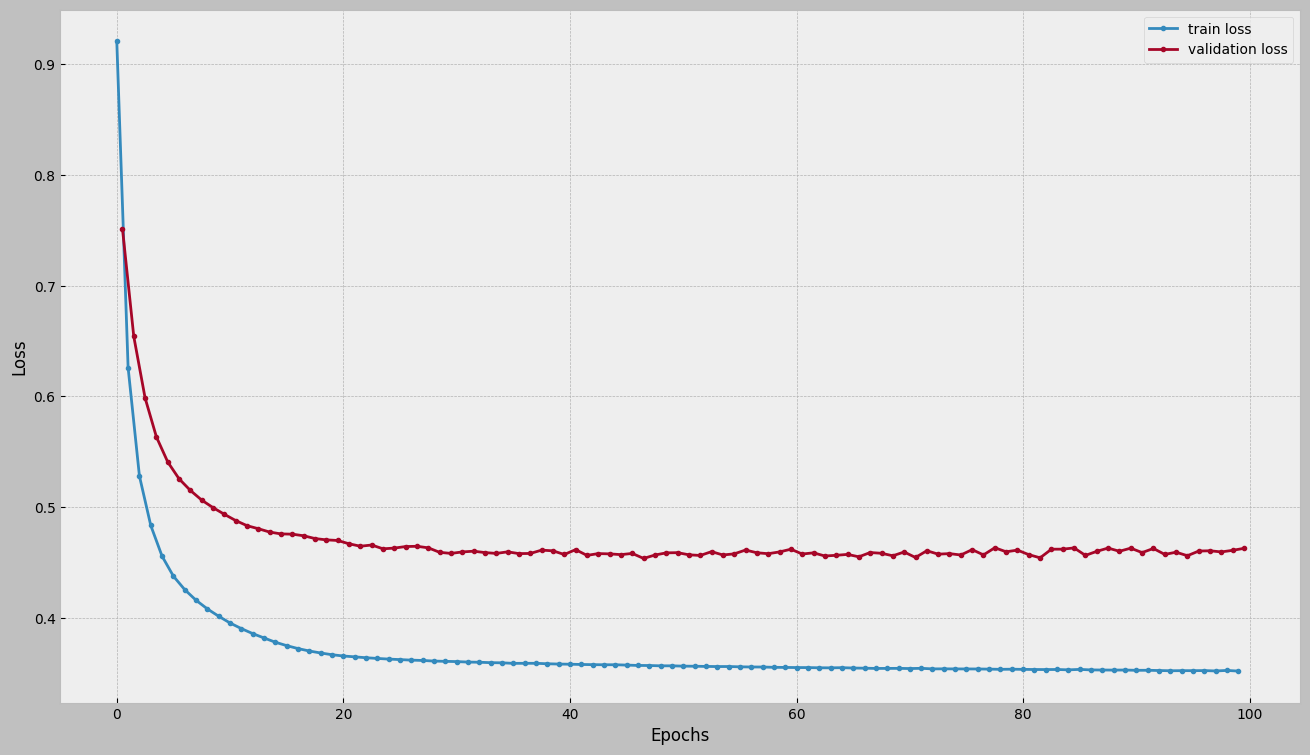

In [29]:
plt.plot(history.history['loss'], label='train loss', marker='.')
plt.plot(np.array(history.epoch) + .5, 
         history.history['val_loss'], label='validation loss', marker='.')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

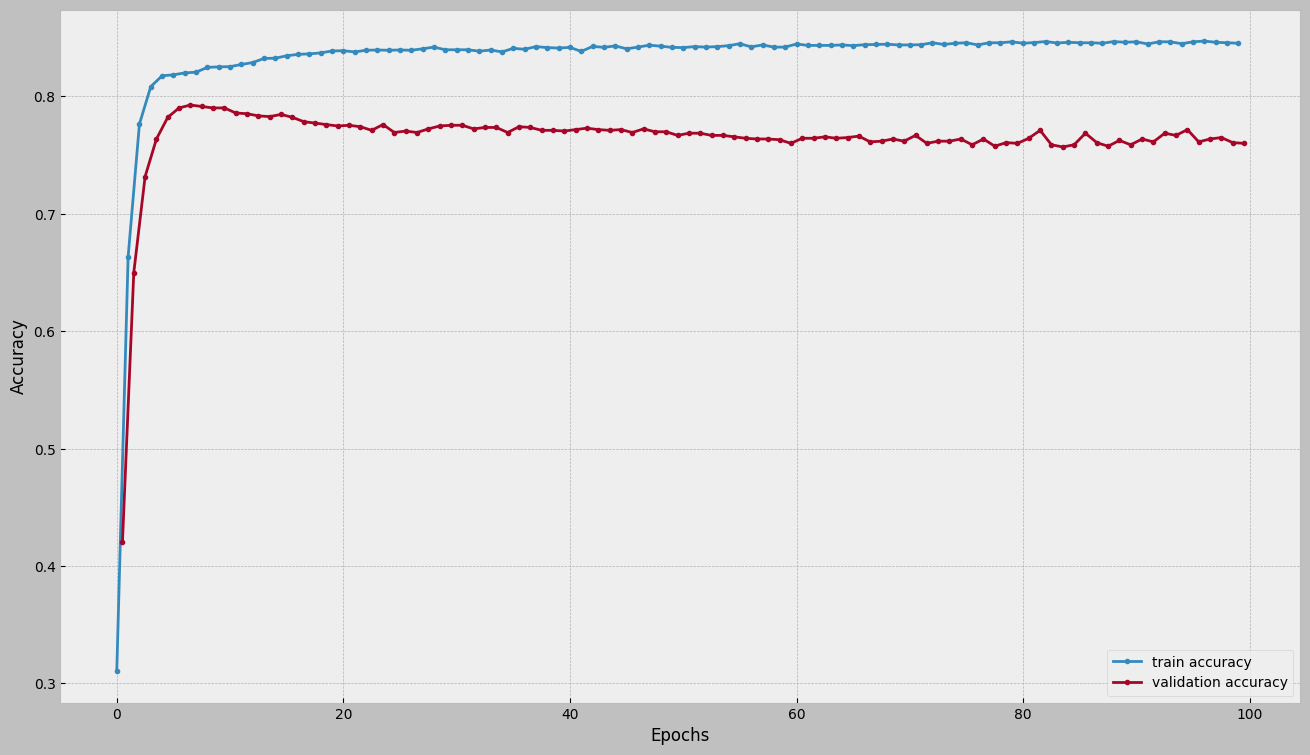

In [30]:
plt.plot(history.history['acc'], label='train accuracy', marker='.')
plt.plot(np.array(history.epoch) + .5, 
         history.history['val_acc'], label='validation accuracy', marker='.')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

# Train / Validation / Test
- Good practice https://dashee87.github.io/data%20science/deep%20learning/python/another-keras-tutorial-for-neural-network-beginners/

In [31]:
from sklearn.model_selection import train_test_split

# Store the scaler in a file; You'll need it to make predictions on new inputs
scaler = StandardScaler()
X_ = scaler.fit_transform(X)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_trn, X_tst, y_trn, y_tst = train_test_split(X_, y, test_size=0.2, stratify=y)
X_trn, X_val, y_trn, y_val = train_test_split(X_trn, y_trn, test_size=0.25, stratify=y_trn)

len(y_trn), len(y_val), len(y_tst)

(3897, 1300, 1300)

In [32]:
neural_net = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X.shape[1],)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [33]:
callbacks = []
callbacks.append(keras.callbacks.EarlyStopping(monitor='val_loss', patience=10))
callbacks.append(keras.callbacks.ModelCheckpoint('neural_net.h5', monitor='val_acc',
                                                 save_weights_only=False, save_best_only=True))

neural_net.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['acc'])
neural_net.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77 (308.00 B)

 Trainable params: 77 (308.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = neural_net.fit(X_trn, y_trn, validation_data=(X_val, y_val), batch_size=32, epochs=100,
                         shuffle=False, callbacks=callbacks)

neural_net = keras.models.load_model('neural_net.h5')

Epoch 1/100
110/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.7993 - loss: 0.5223

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8034 - loss: 0.4941 - val_acc: 0.8038 - val_loss: 0.4582
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4479 - val_acc: 0.8038 - val_loss: 0.4318
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4319 - val_acc: 0.8038 - val_loss: 0.4189
Epoch 4/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4237 - val_acc: 0.8038 - val_loss: 0.4111
Epoch 5/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4182 - val_acc: 0.8038 - val_loss: 0.4056
Epoch 6/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4140 - val_acc: 0.8038 - val_loss: 0.4014
Epoch 7/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4108 - val_acc: 0.8038 - val_loss: 0.3983
Epoch 8/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4082 - val_acc: 0.8038 - val_loss: 0.3957
Epoch 9/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8052 - loss: 0.3973 - val_acc: 0.8185 - val_loss: 0.3854
Epoch 15/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8181 - loss: 0.3961 - val_acc: 0.8185 - val_loss: 0.3844
Epoch 16/100
 96/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8205 - loss: 0.3906

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8191 - loss: 0.3950 - val_acc: 0.8208 - val_loss: 0.3834
Epoch 17/100
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.8217 - loss: 0.3895

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8204 - loss: 0.3939 - val_acc: 0.8246 - val_loss: 0.3825
Epoch 18/100
 95/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8224 - loss: 0.3881

...

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8237 - loss: 0.3882 - val_acc: 0.8308 - val_loss: 0.3776
Epoch 24/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8253 - loss: 0.3873 - val_acc: 0.8308 - val_loss: 0.3771
Epoch 25/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8268 - loss: 0.3866 - val_acc: 0.8300 - val_loss: 0.3766
Epoch 26/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8273 - loss: 0.3858 - val_acc: 0.8308 - val_loss: 0.3761
Epoch 27/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8281 - loss: 0.3852 - val_acc: 0.8308 - val_loss: 0.3756
Epoch 28/100
106/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.8311 - loss: 0.3787

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8291 - loss: 0.3845 - val_acc: 0.8315 - val_loss: 0.3752
Epoch 29/100
117/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.8329 - loss: 0.3782

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8312 - loss: 0.3838 - val_acc: 0.8354 - val_loss: 0.3749
Epoch 30/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8301 - loss: 0.3833 - val_acc: 0.8354 - val_loss: 0.3746
Epoch 31/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8299 - loss: 0.3827 - val_acc: 0.8338 - val_loss: 0.3743
Epoch 32/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8304 - loss: 0.3822 - val_acc: 0.8338 - val_loss: 0.3739
Epoch 33/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8304 - loss: 0.3818 - val_acc: 0.8346 - val_loss: 0.3736
Epoch 34/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8314 - loss: 0.3814 - val_acc: 0.8338 - val_loss: 0.3733
Epoch 35/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8322 - loss: 0.3810 - val_acc: 0.8338 - val_loss: 0.3730
Epoch 36/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8324 - loss: 0.3805 - val_acc: 0.8331 - val_loss: 0.3728
Epoch 37/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8332 - loss: 0.3736 - val_acc: 0.8362 - val_loss: 0.3668
Epoch 62/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8327 - loss: 0.3734 - val_acc: 0.8354 - val_loss: 0.3667
Epoch 63/100
120/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.8307 - loss: 0.3665

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8327 - loss: 0.3732 - val_acc: 0.8369 - val_loss: 0.3665
Epoch 64/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8322 - loss: 0.3730 - val_acc: 0.8354 - val_loss: 0.3663
Epoch 65/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8324 - loss: 0.3728 - val_acc: 0.8338 - val_loss: 0.3661
Epoch 66/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8322 - loss: 0.3727 - val_acc: 0.8354 - val_loss: 0.3658
Epoch 67/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8322 - loss: 0.3725 - val_acc: 0.8338 - val_loss: 0.3657
Epoch 68/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8319 - loss: 0.3723 - val_acc: 0.8338 - val_loss: 0.3655
Epoch 69/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8327 - loss: 0.3721 - val_acc: 0.8338 - val_loss: 0.3653
Epoch 70/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8332 - loss: 0.3719 - val_acc: 0.8331 - val_loss: 0.3652
Epoch 71/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

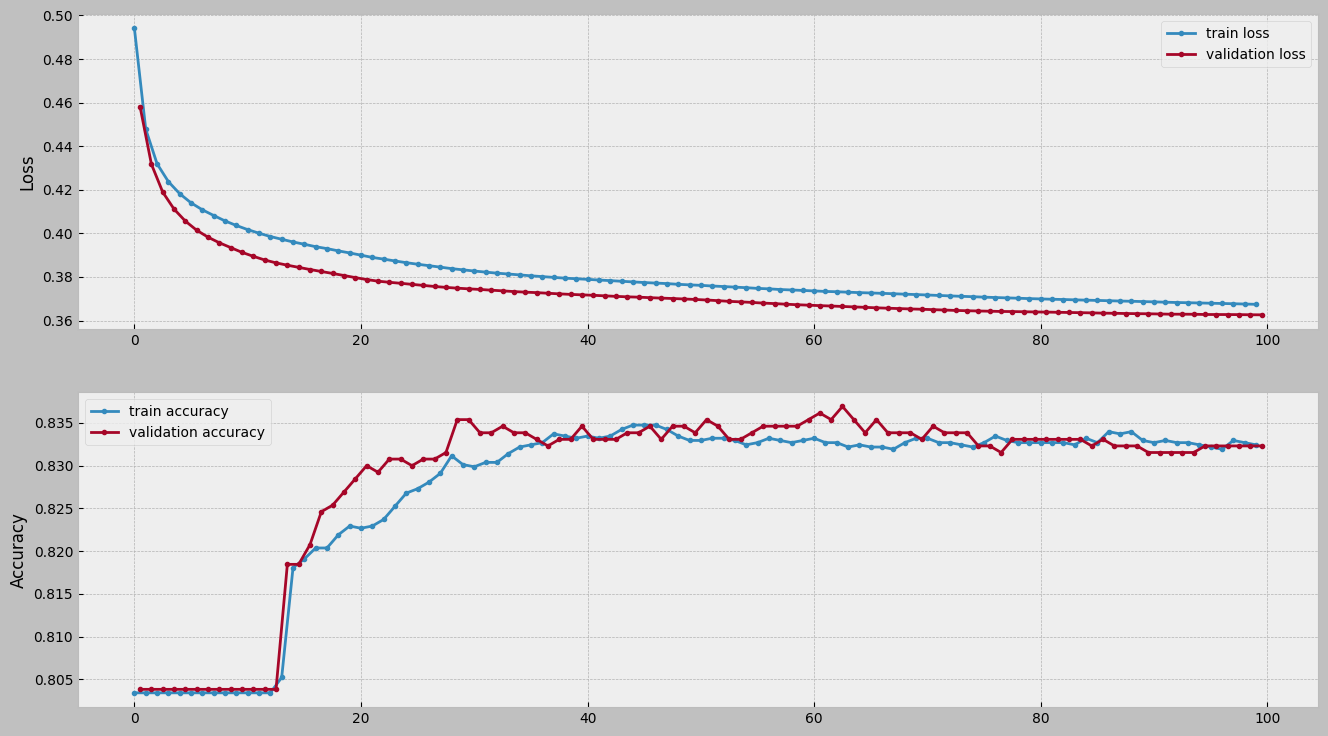

In [35]:
fig, (ax0, ax1) = plt.subplots(nrows=2)

ax0.plot(history.history['loss'], label='train loss', marker='.')
ax0.plot(np.array(history.epoch) + .5, 
         history.history['val_loss'], label='validation loss', marker='.')
ax0.set_ylabel('Loss')
ax0.legend();

ax1.plot(history.history['acc'], label='train accuracy', marker='.')
ax1.plot(np.array(history.epoch) + .5, 
         history.history['val_acc'], label='validation accuracy', marker='.')
ax1.set_ylabel('Accuracy')
ax1.legend();

In [36]:
neural_net.evaluate(X_tst, y_tst, verbose=False)

[0.3849625289440155, 0.8199999928474426]

In [37]:
y_hat = neural_net.predict(X_tst, verbose=False).ravel()

print(classification_report(y_tst, y_hat > .5, target_names=['bad', 'good']))

              precision    recall  f1-score   support

         bad       0.85      0.95      0.89      1044
        good       0.58      0.30      0.39       256

    accuracy                           0.82      1300
   macro avg       0.72      0.62      0.64      1300
weighted avg       0.79      0.82      0.80      1300



/tmp/ipykernel_19601/3871357334.py:3: RuntimeWarning: divide by zero encountered in divide
  f1 = 2 / (1 / prec + 1 / rec)


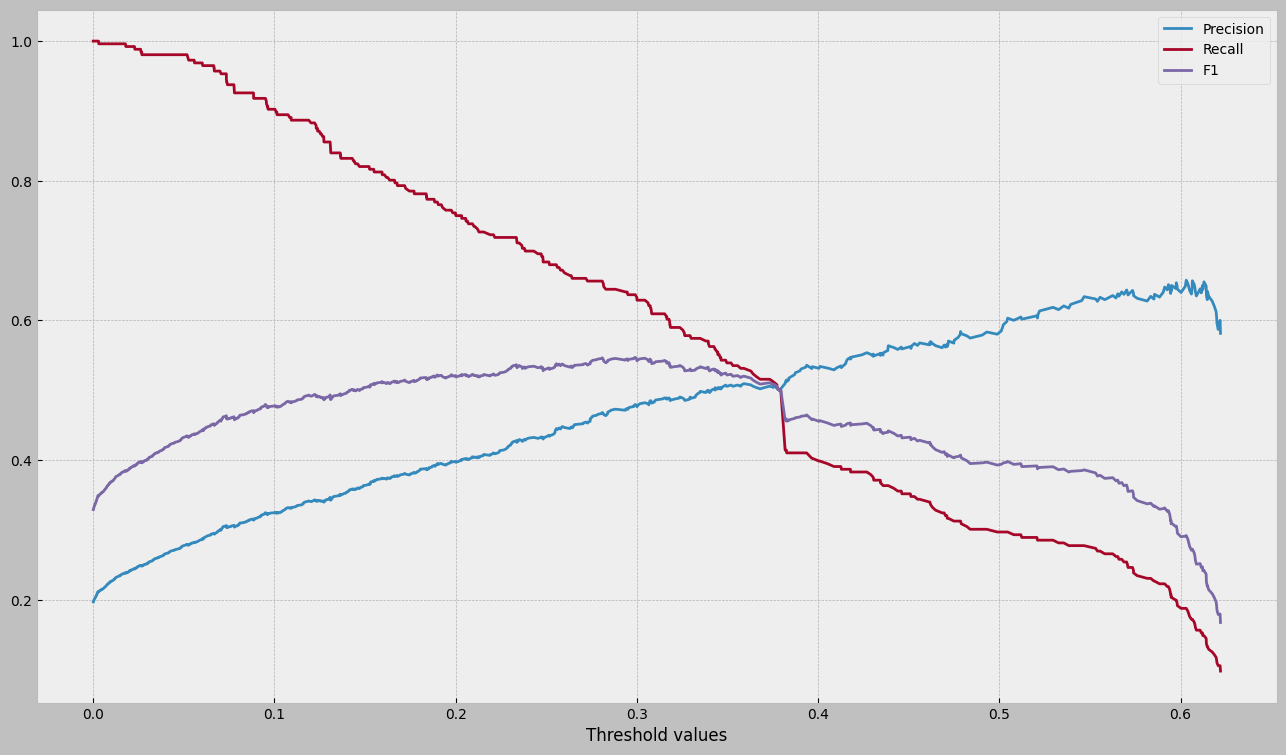

In [38]:
prec, rec, t = precision_recall_curve(y_tst, y_hat)

f1 = 2 / (1 / prec + 1 / rec)

plt.plot(t, prec[:-1], label='Precision')
plt.plot(t, rec[:-1], label='Recall')
plt.plot(t, f1[:-1], label='F1')
plt.xlabel('Threshold values')
plt.legend();

In [39]:
i = f1.argmax()
prec[i], rec[i], t[i]

(np.float64(0.47941176470588237),
 np.float64(0.63671875),
 np.float32(0.29911435))

# So only classification?

| Type of problem | Final activation function | Loss function | Useful metrics |
|:---|:---|:---|:---|
| Binary classification | sigmoid | binary_crossentropy | (binary_)accuracy, f1 score |
| Categorical classification | softmax | categorical_crossentropy | (categorical_)accuracy, f1 score|
| Multi-label classification | sigmoid | binary_crossentropy | binary_accuracy |
| (Multi-)Regression | linear, relu, ... | mse / mean_squared_error | R<sup>2</sup> (custom implementation) |

[Scikit-learn's metrics documentation](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

[TF.Keras losses documentation](https://www.tensorflow.org/api_docs/python/tf/keras/losses)

[TF.Keras metrics documentation](https://www.tensorflow.org/api_docs/python/tf/keras/metrics)